# App-13 : Le Probleme du Voyageur de Commerce (TSP)

**Navigation** : [<< Portfolio](../Hybrid/App-10-Portfolio.ipynb) | [Index](../README.md) | [Foundations >>](../../Part1-Foundations/README.md)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Formaliser** le TSP comme un probleme d'optimisation combinatoire
2. **Implementer** des heuristiques constructives (Plus Proche Voisin)
3. **Appliquer** des metaheuristiques (Recuit Simule, AG, ACO)
4. **Comparer** les performances avec OR-Tools et l'amelioration 2-opt

### Prerequis
- Python 3.10+ (numpy, matplotlib, scipy)
- Search-4 : Recherche locale (Simulated Annealing)
- Search-5 : Algorithmes genetiques

### Duree estimee : 50 minutes

> **Source** : Adapte du projet etudiant ECE 2026 -- Groupe 03 (MonteiroTour).
>
> **Voir aussi** : Le notebook [Search-11-Metaheuristics](../../Part1-Foundations/Search-11-Metaheuristics.ipynb) pour une etude approfondie des metaheuristiques.

## 1. Introduction au TSP

### Definition

Le **Probleme du Voyageur de Commerce** (Traveling Salesman Problem, TSP) est l'un des problemes d'optimisation les plus celebres en informatique.

**Enonce** : Etant donne un ensemble de villes et les distances entre chaque paire de villes, trouver le plus court parcours qui visite chaque ville exactement une fois et revient au point de depart.

### Formalisation mathematique

**Variables de decision** : $x_{ij} = 1$ si l'arete $(i,j)$ est dans la tournee

**Fonction objectif** : Minimiser $\\sum_{i,j} d_{ij} \\cdot x_{ij}$

**Contraintes** :
- Chaque ville est visitee exactement une fois : $\\sum_j x_{ij} = 1$ pour tout $i$
- Chaque ville est quittee exactement une fois : $\\sum_i x_{ij} = 1$ pour tout $j$
- Pas de sous-tournees (contraintes de subtour elimination)

### Complexite

| Propriete | Valeur |
|-----------|--------|
| Nombre de solutions | $(n-1)!/2$ (symetrie) |
| n = 10 | 181,440 solutions |
| n = 15 | ~43 milliards solutions |
| n = 20 | ~6e16 solutions |
| Statut | NP-difficile |

### Applications reelles

- **Logistique** : Tournees de livraison, collecte de dechets
- **Fabrication** : Peracage de circuits imprimes, decoupe laser
- **Genomique** : Assemblage de sequences ADN
- **Astronomie** : Planification d'observations telescopiques

In [1]:
# Imports
import sys
import time
import random
import math
from typing import List, Tuple, Callable, Optional
from copy import deepcopy
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

%matplotlib inline

print("Environnement pret pour le TSP.")
print(f"Python: {sys.version}")

Environnement pret pour le TSP.
Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


## 2. Formalisation du Probleme

Nous allons definir une classe `TSPInstance` pour representer le probleme.

Instance: TSP-10
Nombre de villes: 10
Matrice de distances: (10, 10)


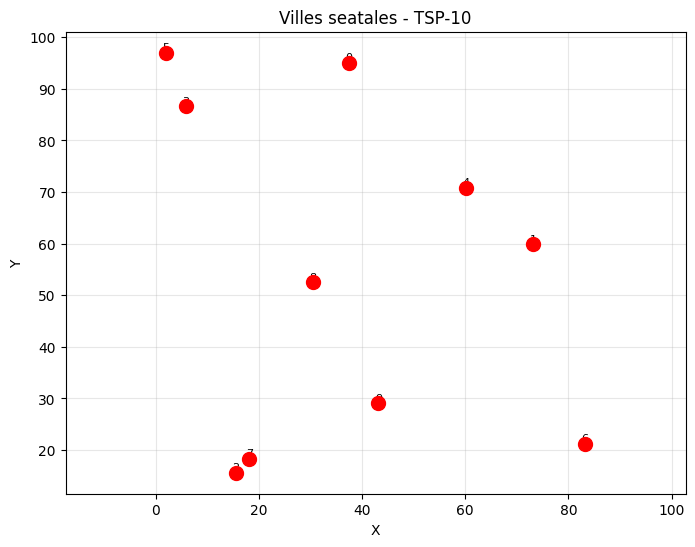

In [2]:
class TSPInstance:
    """Representation d'une instance du TSP."""
    
    def __init__(self, villes: np.ndarray, nom: str = "TSP", distances: Optional[np.ndarray] = None):
        """
        Args:
            villes: Coordonnees (n, 2) des villes
            nom: Nom de l'instance
            distances: Matrice des distances (n, n), optionnelle (utile pour l'ATSP)
        """
        self.villes = villes
        self.nom = nom
        self.n = len(villes)
        if distances is None:
            self.distances = self._calculer_distances()
        else:
            self.distances = np.array(distances, dtype=float)
            if self.distances.shape != (self.n, self.n):
                raise ValueError(f"La matrice des distances doit etre de taille {(self.n, self.n)}")
    
    def _calculer_distances(self) -> np.ndarray:
        """Calcule la matrice des distances euclidiennes (symetrique)."""
        diff = self.villes[:, np.newaxis, :] - self.villes[np.newaxis, :, :]
        return np.sqrt(np.sum(diff**2, axis=2))
    
    def cout_tournee(self, tournee: List[int]) -> float:
        """Calcule le cout total d'une tournee."""
        cout = 0.0
        for i in range(len(tournee)):
            cout += self.distances[tournee[i], tournee[(i+1) % self.n]]
        return cout
    
    @staticmethod
    def generer_aleatoire(n: int, seed: int = 42) -> 'TSPInstance':
        """Genere une instance aleatoire symetrique avec n villes."""
        np.random.seed(seed)
        villes = np.random.rand(n, 2) * 100
        return TSPInstance(villes, f"TSP-{n}")

    @staticmethod
    def generer_aleatoire_asymetrique(n: int, seed: int = 42) -> 'TSPInstance':
        """Genere une instance aleatoire asymetrique (ATSP) avec n villes."""
        np.random.seed(seed)
        villes = np.random.rand(n, 2) * 100
        base = TSPInstance(villes, f"ATSP-{n}")
        distances = base.distances.copy()
        facteur = np.random.uniform(0.7, 1.3, size=(n, n))
        distances = distances * facteur
        np.fill_diagonal(distances, 0.0)
        return TSPInstance(villes, f"ATSP-{n}", distances=distances)
    
    def afficher(self, tournee: Optional[List[int]] = None, titre: str = "") -> None:
        """Visualise la tournee."""
        plt.figure(figsize=(8, 6))
        
        # Villes
        plt.scatter(self.villes[:, 0], self.villes[:, 1], c='red', s=100, zorder=5)
        
        # Numeros des villes
        for i, (x, y) in enumerate(self.villes):
            plt.annotate(str(i), (x, y), fontsize=8, ha='center', va='bottom')
        
        # Tournee
        if tournee is not None:
            tournee_complete = tournee + [tournee[0]]
            coords = self.villes[tournee_complete]
            plt.plot(coords[:, 0], coords[:, 1], 'b-', linewidth=1.5, alpha=0.7)
        
        plt.title(f"{titre} - {self.nom}")
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.show()

# Test avec une petite instance
tsp = TSPInstance.generer_aleatoire(10)
print(f"Instance: {tsp.nom}")
print(f"Nombre de villes: {tsp.n}")
print(f"Matrice de distances: {tsp.distances.shape}")
tsp.afficher(titre="Villes seatales")

## 3. Methodes Exates (Reference)

### 3.1 Force Brute

Exploration de toutes les permutations. **Utilisable uniquement pour n <= 10**.

Solution optimale: 277.23
Temps de calcul: 0.007s


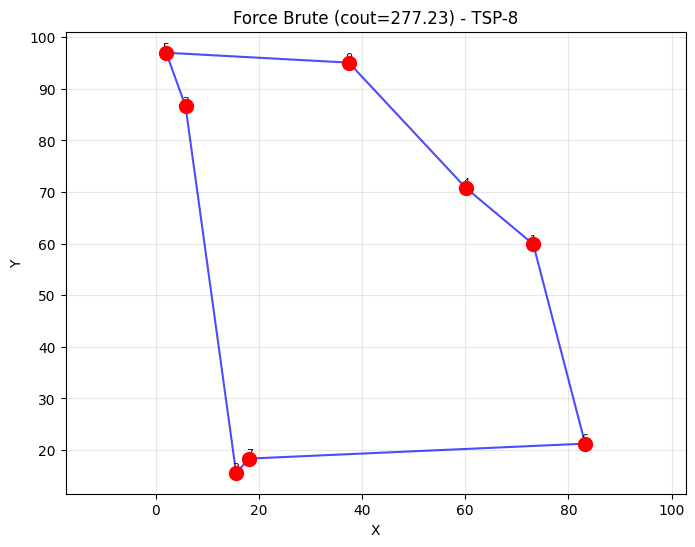

In [3]:
def brute_force(tsp: TSPInstance) -> Tuple[List[int], float]:
    """Resolution par force brute - O((n-1)!)."""
    meilleure_tournee = None
    meilleur_cout = float('inf')
    
    # Fixer la premiere ville pour eviter les symetries
    for perm in permutations(range(1, tsp.n)):
        tournee = [0] + list(perm)
        cout = tsp.cout_tournee(tournee)
        if cout < meilleur_cout:
            meilleur_cout = cout
            meilleure_tournee = tournee
    
    return meilleure_tournee, meilleur_cout

# Test sur petite instance
tsp_small = TSPInstance.generer_aleatoire(8)
start = time.time()
tournee_opt, cout_opt = brute_force(tsp_small)
temps_brute = time.time() - start

print(f"Solution optimale: {cout_opt:.2f}")
print(f"Temps de calcul: {temps_brute:.3f}s")
tsp_small.afficher(tournee_opt, f"Force Brute (cout={cout_opt:.2f})")

## 4. Heuristiques Constructives

### 4.1 Plus Proche Voisin (Nearest Neighbor)

Heuristique gloutonne qui construit une solution en O(n^2).

Solution NN: 465.04
Temps: 0.10ms


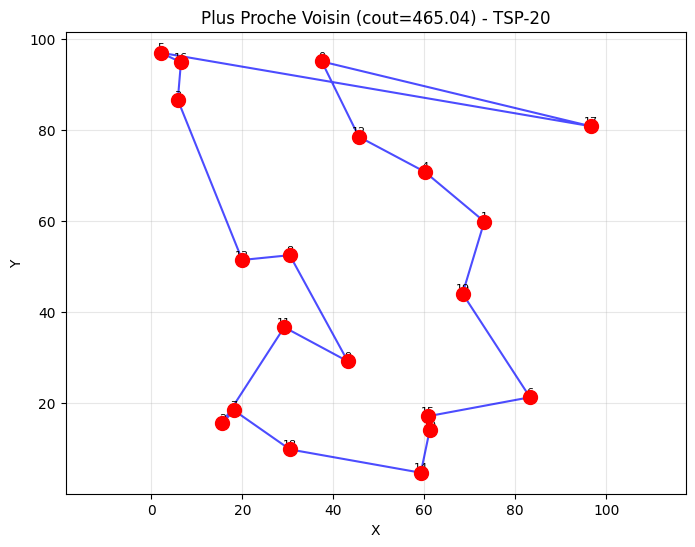

In [4]:
def plus_proche_voisin(tsp: TSPInstance, depart: int = 0) -> Tuple[List[int], float]:
    """Heuristique du plus proche voisin - O(n^2)."""
    non_visitees = set(range(tsp.n))
    non_visitees.remove(depart)
    tournee = [depart]
    
    while non_visitees:
        ville_actuelle = tournee[-1]
        # Trouver la ville la plus proche
        meilleure_ville = min(non_visitees, 
                              key=lambda v: tsp.distances[ville_actuelle, v])
        tournee.append(meilleure_ville)
        non_visitees.remove(meilleure_ville)
    
    return tournee, tsp.cout_tournee(tournee)

# Test
tsp_medium = TSPInstance.generer_aleatoire(20)
start = time.time()
tournee_nn, cout_nn = plus_proche_voisin(tsp_medium)
temps_nn = time.time() - start

print(f"Solution NN: {cout_nn:.2f}")
print(f"Temps: {temps_nn*1000:.2f}ms")
tsp_medium.afficher(tournee_nn, f"Plus Proche Voisin (cout={cout_nn:.2f})")

## 5. Recherche Locale : 2-opt

L'amelioration **2-opt** est une recherche locale qui inverse des segments de la tournee.

Solution NN + 2-opt: 386.63
Amelioration: 16.9%
Temps: 3.48ms


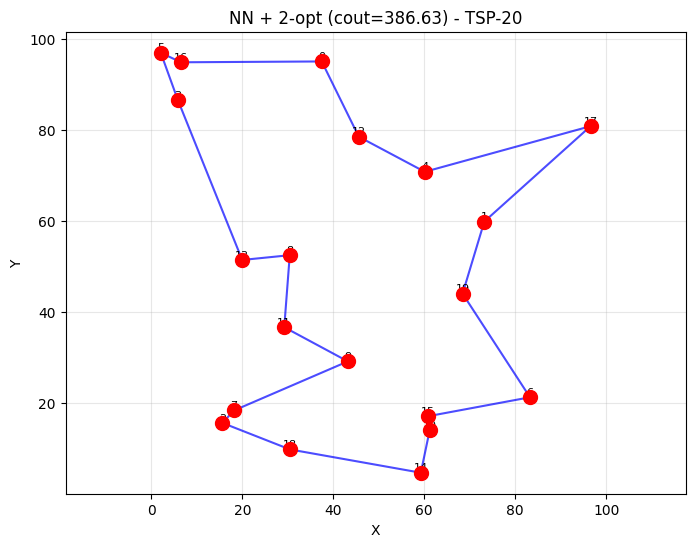

In [5]:
def two_opt(tsp: TSPInstance, tournee: List[int], max_iter: int = 1000) -> Tuple[List[int], float]:
    """Amelioration 2-opt d'une tournee."""
    tournee = tournee.copy()
    ameliore = True
    iterations = 0
    
    while ameliore and iterations < max_iter:
        ameliore = False
        for i in range(tsp.n - 1):
            for j in range(i + 2, tsp.n):
                # Inverser le segment [i+1:j]
                nouvelle_tournee = tournee[:i+1] + tournee[i+1:j+1][::-1] + tournee[j+1:]
                nouveau_cout = tsp.cout_tournee(nouvelle_tournee)
                
                if nouveau_cout < tsp.cout_tournee(tournee):
                    tournee = nouvelle_tournee
                    ameliore = True
        iterations += 1
    
    return tournee, tsp.cout_tournee(tournee)

# Ameliorer la solution NN
start = time.time()
tournee_2opt, cout_2opt = two_opt(tsp_medium, tournee_nn)
temps_2opt = time.time() - start

print(f"Solution NN + 2-opt: {cout_2opt:.2f}")
print(f"Amelioration: {(cout_nn - cout_2opt)/cout_nn*100:.1f}%")
print(f"Temps: {temps_2opt*1000:.2f}ms")
tsp_medium.afficher(tournee_2opt, f"NN + 2-opt (cout={cout_2opt:.2f})")

## 6. Recuit Simule (Simulated Annealing)

Metaheuristique basee sur l'analogie avec la metallurgie. Permet des mouvements degradants avec une probabilite decroissante.

Solution SA: 386.43
Temps: 0.95s


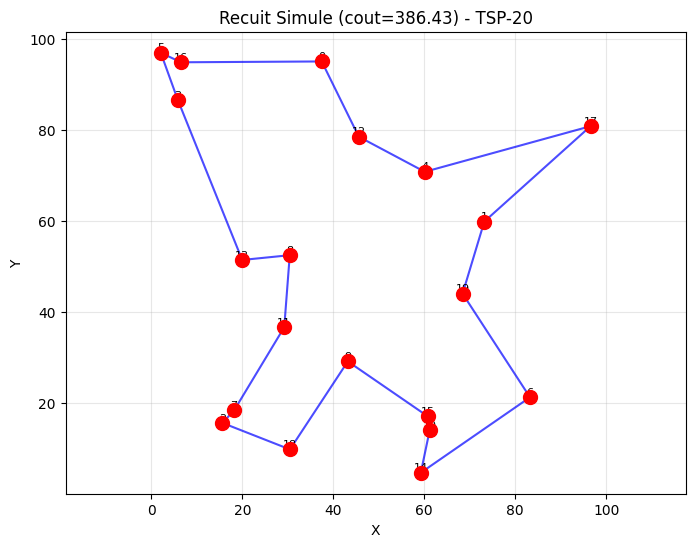

In [6]:
def simulated_annealing_tsp(tsp: TSPInstance, 
                            tournee_initiale: List[int],
                            T0: float = 1000.0,
                            T_min: float = 0.1,
                            alpha: float = 0.995,
                            iterations_par_T: int = 100) -> Tuple[List[int], float, List[float]]:
    """Recuit simule pour le TSP."""
    tournee = tournee_initiale.copy()
    cout_actuel = tsp.cout_tournee(tournee)
    meilleure_tournee = tournee.copy()
    meilleur_cout = cout_actuel
    
    T = T0
    historique_couts = []
    
    while T > T_min:
        for _ in range(iterations_par_T):
            # Generer un voisin par echange aleatoire
            i, j = sorted(random.sample(range(tsp.n), 2))
            nouvelle_tournee = tournee.copy()
            nouvelle_tournee[i], nouvelle_tournee[j] = nouvelle_tournee[j], nouvelle_tournee[i]
            nouveau_cout = tsp.cout_tournee(nouvelle_tournee)
            
            delta = nouveau_cout - cout_actuel
            
            # Accepter le mouvement
            if delta < 0 or random.random() < math.exp(-delta / T):
                tournee = nouvelle_tournee
                cout_actuel = nouveau_cout
                
                if cout_actuel < meilleur_cout:
                    meilleure_tournee = tournee.copy()
                    meilleur_cout = cout_actuel
        
        historique_couts.append(meilleur_cout)
        T *= alpha
    
    return meilleure_tournee, meilleur_cout, historique_couts

# Test
random.seed(42)
start = time.time()
tournee_sa, cout_sa, hist_sa = simulated_annealing_tsp(tsp_medium, tournee_nn)
temps_sa = time.time() - start

print(f"Solution SA: {cout_sa:.2f}")
print(f"Temps: {temps_sa:.2f}s")
tsp_medium.afficher(tournee_sa, f"Recuit Simule (cout={cout_sa:.2f})")

Visualisation des resultats.

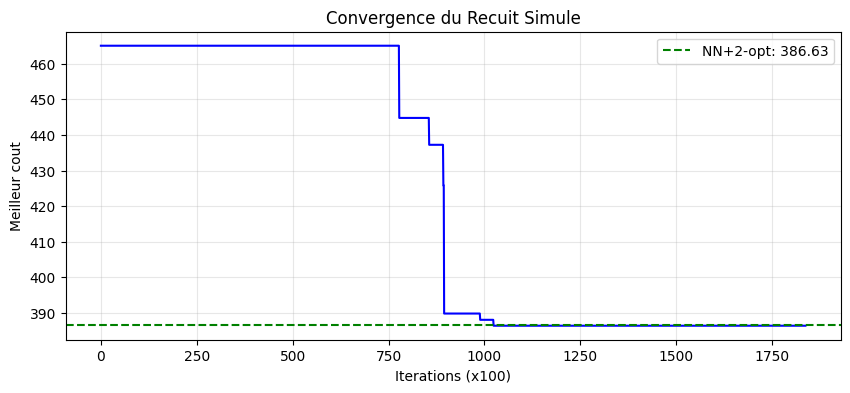

In [7]:
# Visualisation de la convergence
plt.figure(figsize=(10, 4))
plt.plot(hist_sa, 'b-', linewidth=1.5)
plt.axhline(y=cout_2opt, color='g', linestyle='--', label=f'NN+2-opt: {cout_2opt:.2f}')
plt.xlabel('Iterations (x100)')
plt.ylabel('Meilleur cout')
plt.title('Convergence du Recuit Simule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Algorithme Genetique

Optimisation par evolution artificielle : selection, crossover, mutation.

Solution GA: 500.12
Temps: 0.10s


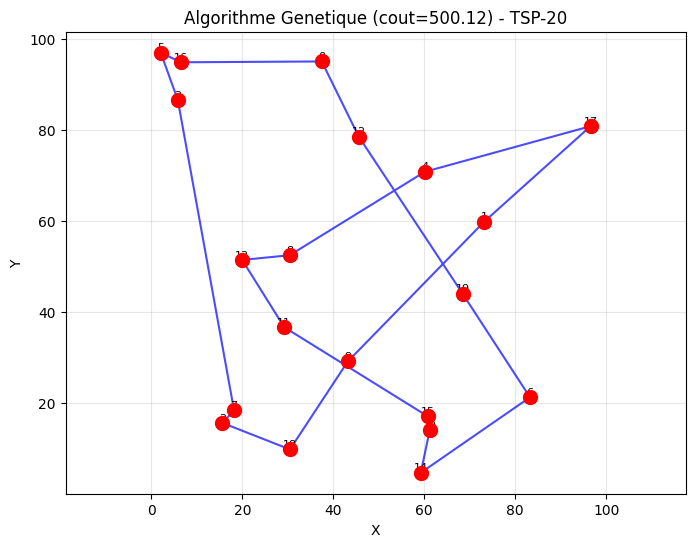

In [8]:
def algorithme_genetique_tsp(tsp: TSPInstance,
                               taille_pop: int = 50,
                               generations: int = 100,
                               taux_mutation: float = 0.1,
                               elitisme: int = 2) -> Tuple[List[int], float, List[float]]:
    """Algorithme genetique pour le TSP."""
    
    def creer_individu() -> List[int]:
        """Cree une tournee aleatoire."""
        tournee = list(range(tsp.n))
        random.shuffle(tournee)
        return tournee
    
    def fitness(tournee: List[int]) -> float:
        """Fitness inverse (plus petit cout = meilleur)."""
        return 1.0 / tsp.cout_tournee(tournee)
    
    def crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
        """Crossover OX (Order Crossover)."""
        n = len(parent1)
        i, j = sorted(random.sample(range(n), 2))
        
        # Enfant 1
        enfant1 = [None] * n
        enfant1[i:j+1] = parent1[i:j+1]
        manquants = [v for v in parent2 if v not in enfant1[i:j+1]]
        idx = 0
        for k in range(n):
            if enfant1[k] is None:
                enfant1[k] = manquants[idx]
                idx += 1
        
        # Enfant 2
        enfant2 = [None] * n
        enfant2[i:j+1] = parent2[i:j+1]
        manquants = [v for v in parent1 if v not in enfant2[i:j+1]]
        idx = 0
        for k in range(n):
            if enfant2[k] is None:
                enfant2[k] = manquants[idx]
                idx += 1
        
        return enfant1, enfant2
    
    def muter(tournee: List[int]) -> List[int]:
        """Mutation par echange de deux villes."""
        tournee = tournee.copy()
        i, j = random.sample(range(len(tournee)), 2)
        tournee[i], tournee[j] = tournee[j], tournee[i]
        return tournee
    
    # Initialisation
    population = [creer_individu() for _ in range(taille_pop)]
    historique = []
    
    for gen in range(generations):
        # Evaluation
        population.sort(key=lambda x: tsp.cout_tournee(x))
        historique.append(tsp.cout_tournee(population[0]))
        
        # Selection et reproduction
        nouvelle_pop = population[:elitisme]
        
        while len(nouvelle_pop) < taille_pop:
            # Tournoi
            candidats = random.sample(population[:taille_pop//2], 2)
            parent1 = min(candidats, key=lambda x: tsp.cout_tournee(x))
            candidats = random.sample(population[:taille_pop//2], 2)
            parent2 = min(candidats, key=lambda x: tsp.cout_tournee(x))
            
            enfant1, enfant2 = crossover(parent1, parent2)
            nouvelle_pop.extend([enfant1, enfant2])
        
        # Mutation
        for i in range(elitisme, taille_pop):
            if random.random() < taux_mutation:
                nouvelle_pop[i] = muter(nouvelle_pop[i])
        
        population = nouvelle_pop[:taille_pop]
    
    meilleure = population[0]
    return meilleure, tsp.cout_tournee(meilleure), historique

# Test
random.seed(42)
start = time.time()
tournee_ga, cout_ga, hist_ga = algorithme_genetique_tsp(tsp_medium, taille_pop=50, generations=100)
temps_ga = time.time() - start

print(f"Solution GA: {cout_ga:.2f}")
print(f"Temps: {temps_ga:.2f}s")
tsp_medium.afficher(tournee_ga, f"Algorithme Genetique (cout={cout_ga:.2f})")

## 8. Colonie de Fourmis (ACO)

Algorithme bio-inspire base sur le comportement des fourmis cherchant de la nourriture.

Solution ACO: 386.63
Temps: 0.81s


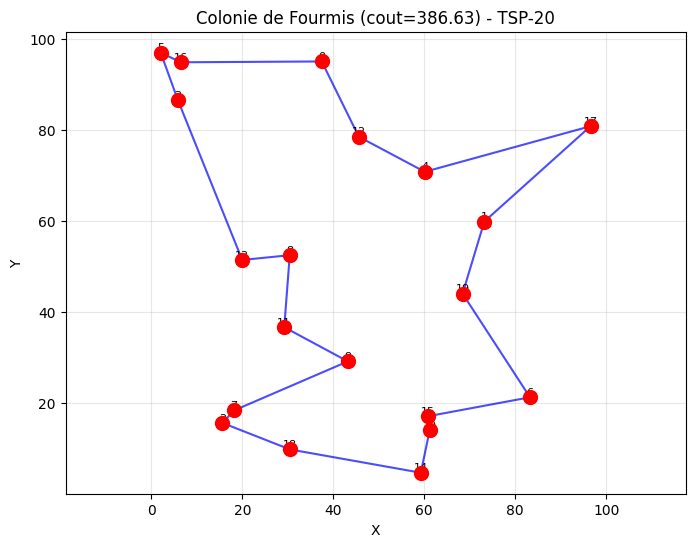

In [9]:
def colonie_fourmis(tsp: TSPInstance,
                     n_fourmis: int = 20,
                     n_iterations: int = 100,
                     alpha: float = 1.0,  # Influence pheromones
                     beta: float = 2.0,   # Influence visibilite
                     rho: float = 0.5,    # Evaporation
                     Q: float = 100.0) -> Tuple[List[int], float, List[float]]:
    """Algorithme de colonie de fourmis (AS - Ant System)."""
    n = tsp.n
    pheromones = np.ones((n, n)) * 0.1
    
    def choix_ville(ville_actuelle: int, visitees: set, pheromones: np.ndarray) -> int:
        """Choix probabiliste de la prochaine ville."""
        non_visitees = [v for v in range(n) if v not in visitees]
        
        if not non_visitees:
            return -1
        
        # Calcul des probabilites
        probs = []
        for v in non_visitees:
            distance = tsp.distances[ville_actuelle, v]
            if distance > 0:
                tau = pheromones[ville_actuelle, v] ** alpha
                eta = (1.0 / distance) ** beta
                probs.append(tau * eta)
            else:
                probs.append(0.0)
        
        probs = np.array(probs, dtype=float)
        somme = probs.sum()
        if somme <= 0:
            probs = np.ones(len(non_visitees), dtype=float) / len(non_visitees)
        else:
            probs /= somme
        
        return int(np.random.choice(non_visitees, p=probs))
    
    meilleure_tournee = None
    meilleur_cout = float('inf')
    historique = []
    
    for iteration in range(n_iterations):
        tournees = []
        couts = []
        
        # Construction des tournees
        for f in range(n_fourmis):
            ville_depart = f % n
            visitees = {ville_depart}
            tournee = [ville_depart]
            
            while len(tournee) < n:
                prochaine = choix_ville(tournee[-1], visitees, pheromones)
                if prochaine == -1:
                    break
                tournee.append(prochaine)
                visitees.add(prochaine)
            
            tournees.append(tournee)
            couts.append(tsp.cout_tournee(tournee))
        
        # Mise a jour meilleure solution
        for tournee, cout in zip(tournees, couts):
            if cout < meilleur_cout:
                meilleur_cout = cout
                meilleure_tournee = tournee
        
        historique.append(meilleur_cout)
        
        # Evaporation
        pheromones *= (1 - rho)
        
        # Depot de pheromones
        for tournee, cout in zip(tournees, couts):
            if cout <= 0:
                continue
            depot = Q / cout
            for i in range(len(tournee) - 1):
                pheromones[tournee[i], tournee[i + 1]] += depot
                pheromones[tournee[i + 1], tournee[i]] += depot
            # Retour au depart
            if len(tournee) > 1:
                pheromones[tournee[-1], tournee[0]] += depot
                pheromones[tournee[0], tournee[-1]] += depot
    
    return meilleure_tournee, meilleur_cout, historique

# Test
np.random.seed(42)
start = time.time()
tournee_aco, cout_aco, hist_aco = colonie_fourmis(tsp_medium)
temps_aco = time.time() - start

print(f"Solution ACO: {cout_aco:.2f}")
print(f"Temps: {temps_aco:.2f}s")
tsp_medium.afficher(tournee_aco, f"Colonie de Fourmis (cout={cout_aco:.2f})")

## 9. Benchmark Comparatif

Comparons toutes les methodes sur une instance de taille moyenne.

In [10]:
# Benchmark complet
tsp_bench = TSPInstance.generer_aleatoire(30, seed=123)

resultats = {}

# 1. Plus Proche Voisin
start = time.time()
tournee, cout = plus_proche_voisin(tsp_bench)
resultats['NN'] = {'cout': cout, 'temps': time.time() - start}

# 2. NN + 2-opt
start = time.time()
tournee_nn = plus_proche_voisin(tsp_bench)[0]
tournee, cout = two_opt(tsp_bench, tournee_nn)
resultats['NN+2opt'] = {'cout': cout, 'temps': time.time() - start}

# 3. Recuit Simule
random.seed(42)
start = time.time()
tournee, cout, _ = simulated_annealing_tsp(tsp_bench, tournee_nn)
resultats['SA'] = {'cout': cout, 'temps': time.time() - start}

# 4. Algorithme Genetique
random.seed(42)
start = time.time()
tournee, cout, _ = algorithme_genetique_tsp(tsp_bench, taille_pop=30, generations=50)
resultats['GA'] = {'cout': cout, 'temps': time.time() - start}

# 5. ACO
np.random.seed(42)
start = time.time()
tournee, cout, _ = colonie_fourmis(tsp_bench, n_iterations=50)
resultats['ACO'] = {'cout': cout, 'temps': time.time() - start}

# Affichage des resultats
print("=" * 60)
print(f"Benchmark TSP-{tsp_bench.n} villes")
print("=" * 60)
print(f"{'Methode':<15} {'Cout':>10} {'Temps (s)':>12} {'Qualite':>10}")
print("-" * 60)

cout_ref = min(r['cout'] for r in resultats.values())
for methode, res in resultats.items():
    qualite = f"{res['cout']/cout_ref:.2f}x"
    print(f"{methode:<15} {res['cout']:>10.2f} {res['temps']:>12.3f} {qualite:>10}")
print("=" * 60)

Benchmark TSP-30 villes
Methode               Cout    Temps (s)    Qualite
------------------------------------------------------------
NN                  494.69        0.000      1.04x
NN+2opt             489.74        0.007      1.03x
SA                  480.57        1.211      1.01x
GA                  732.23        0.045      1.55x
ACO                 473.68        0.699      1.00x


Visualisation des resultats.

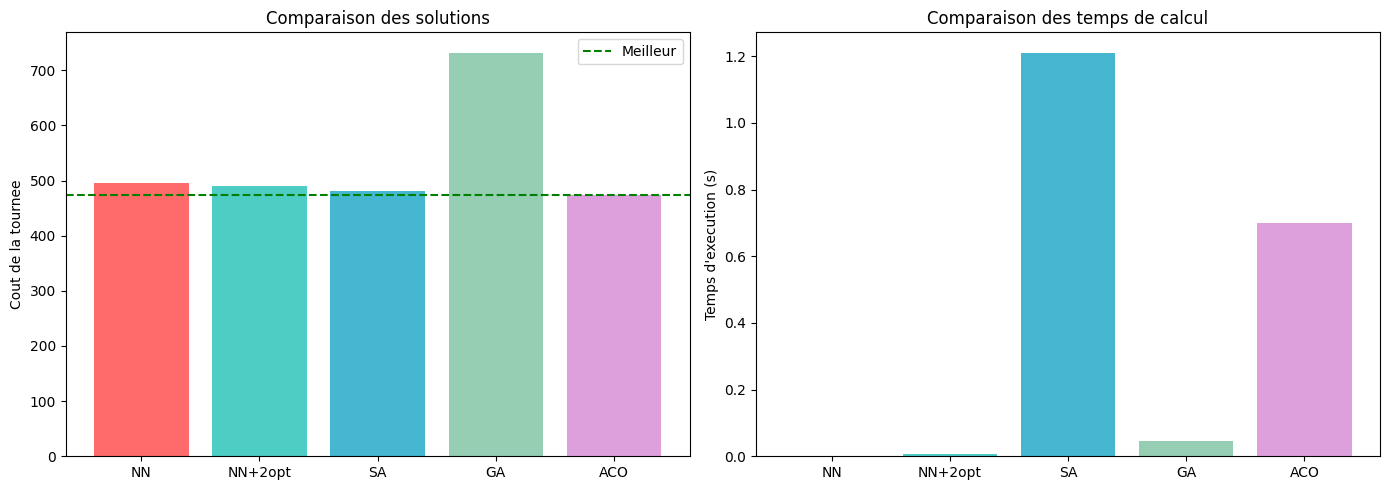

In [11]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique des couts
methodes = list(resultats.keys())
couts = [resultats[m]['cout'] for m in methodes]
couleurs = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#dda0dd']

axes[0].bar(methodes, couts, color=couleurs)
axes[0].axhline(y=min(couts), color='green', linestyle='--', label='Meilleur')
axes[0].set_ylabel('Cout de la tournee')
axes[0].set_title('Comparaison des solutions')
axes[0].legend()

# Graphique des temps
temps = [resultats[m]['temps'] for m in methodes]
axes[1].bar(methodes, temps, color=couleurs)
axes[1].set_ylabel('Temps d\'execution (s)')
axes[1].set_title('Comparaison des temps de calcul')

plt.tight_layout()
plt.show()

## 10. Comparaison avec OR-Tools

Google OR-Tools fournit un solveur TSP optimal.

Solution OR-Tools: 465.53
Temps: 2.01s

Gap vs meilleure metaheuristique: 0.9828x


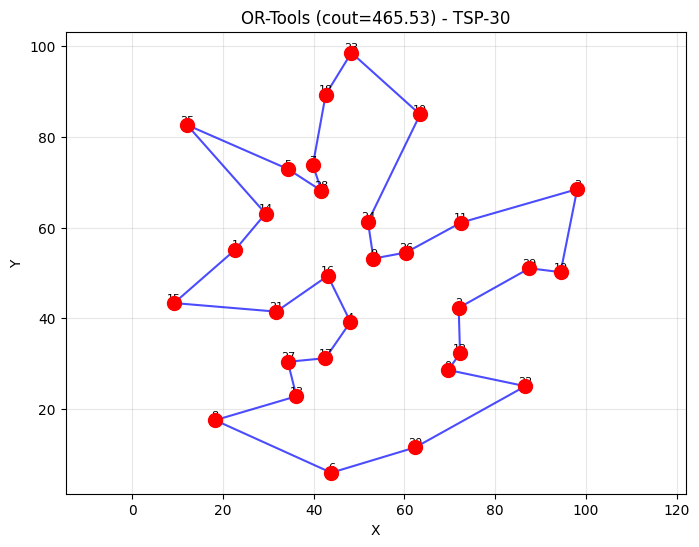

In [12]:
try:
    from ortools.constraint_solver import routing_enums_pb2
    from ortools.constraint_solver import pywrapcp
    
    def ortools_tsp(tsp: TSPInstance, time_limit: int = 5) -> Tuple[List[int], float]:
        """Solveur TSP OR-Tools."""
        manager = pywrapcp.RoutingIndexManager(tsp.n, 1, 0)
        routing = pywrapcp.RoutingModel(manager)
        
        def distance_callback(from_index, to_index):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            return int(tsp.distances[from_node, to_node] * 1000)
        
        transit_callback_index = routing.RegisterTransitCallback(distance_callback)
        routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
        
        search_parameters = pywrapcp.DefaultRoutingSearchParameters()
        search_parameters.first_solution_strategy = (
            routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
        search_parameters.local_search_metaheuristic = (
            routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
        search_parameters.time_limit.seconds = time_limit
        
        solution = routing.SolveWithParameters(search_parameters)
        
        if solution:
            tournee = []
            index = routing.Start(0)
            while not routing.IsEnd(index):
                tournee.append(manager.IndexToNode(index))
                index = solution.Value(routing.NextVar(index))
            return tournee, tsp.cout_tournee(tournee)
        return None, float('inf')
    
    # Test
    start = time.time()
    tournee_ort, cout_ort = ortools_tsp(tsp_bench, time_limit=2)
    temps_ort = time.time() - start
    
    print(f"Solution OR-Tools: {cout_ort:.2f}")
    print(f"Temps: {temps_ort:.2f}s")
    print(f"\nGap vs meilleure metaheuristique: {cout_ort/min(couts):.4f}x")
    
    tsp_bench.afficher(tournee_ort, f"OR-Tools (cout={cout_ort:.2f})")
    
except ImportError:
    print("OR-Tools non installe. Installez avec: pip install ortools")

## Exercices

### Exercice 1 : Heuristique d'Insertion la Moins Chere

Implementez l'heuristique **Cheapest Insertion** qui construit une tournee en inserant chaque ville a la position qui augmente le moins le cout total.

**Indices** :
- Commencez avec une tournee de 3 villes formant un triangle
- Pour chaque ville non visitee, trouvez la meilleure position d'insertion
- Comparez les resultats avec le Plus Proche Voisin

In [13]:
def cheapest_insertion(tsp: TSPInstance) -> Tuple[List[int], float]:
    """
    Heuristique Cheapest Insertion pour le TSP.
    
    Etapes:
    1. Commencer avec une sous-tournee de 3 villes (triangle)
    2. Pour chaque ville non visitee, calculer le cout d'insertion a chaque position
    3. Inserer la ville a la position la moins couteuse
    4. Repeter jusqu'a ce que toutes les villes soient visitees
    
    Returns:
        Tuple (tournee, cout_total)
    """
    # Exercice: Implementez l'heuristique Cheapest Insertion
    #
    # Indice: utilisez tsp.distances[a, b] pour acceder a la distance entre deux villes
    # Indice: le cout d'insertion entre les positions pos et pos+1 se calcule ainsi:
    #   delta = tsp.distances[a, ville] + tsp.distances[ville, b] - tsp.distances[a, b]
    # Indice: tsp.cout_tournee(tournee) retourne le cout total d'une tournee
    #
    n = tsp.n
    if n == 0:
        return [], 0.0
    if n <= 3:
        tournee = list(range(n))
        return tournee, tsp.cout_tournee(tournee)
    
    pass  # Exercice: Implementez cheapest_insertion
print('Fonction cheapest_insertion definie')

Fonction cheapest_insertion definie


Test de l'heuristique Cheapest Insertion : decommentez et executez apres avoir implemente la fonction ci-dessus.


In [14]:
# Test cheapest_insertion
tsp_ci = TSPInstance.generer_aleatoire(20, seed=123)

start = time.time()
try:
    tournee_ci, cout_ci = cheapest_insertion(tsp_ci)
    temps_ci = time.time() - start

    assert len(tournee_ci) == tsp_ci.n
    assert len(set(tournee_ci)) == tsp_ci.n

    print(f"Solution Cheapest Insertion: {cout_ci:.2f}")
    print(f"Temps: {temps_ci*1000:.2f}ms")
    tsp_ci.afficher(tournee_ci, f"Cheapest Insertion (cout={cout_ci:.2f})")
except (TypeError, ValueError, AttributeError) as e:
    print("Exercice a completer : implementez cheapest_insertion().")
    print(f"Attendu : tournee de {tsp_ci.n} villes, assertion de validite.")


Exercice a completer : implementez cheapest_insertion().
Attendu : tournee de 20 villes, assertion de validite.


### Exercice 2 : Operateur de Voisinage Or-opt

L'operateur **Or-opt** consiste a deplacer un segment de 1 a 3 villes consecutives a une autre position de la tournee. Implementez cet operateur.

**Indices** :
- Extrayez un segment de k villes (k = 1, 2 ou 3)
- Reinserez ce segment a une autre position
- Comparez l'amelioration avec 2-opt sur les memes instances

In [15]:
def or_opt(tsp: TSPInstance, tournee: List[int], k_max: int = 3) -> Tuple[List[int], float]:
    """
    Operateur de voisinage Or-opt.
    
    Deplace un segment de k villes (1 <= k <= k_max) vers une autre position
    de la tournee, en retenant le meilleur deplacement.
    
    Args:
        tsp: Instance du TSP
        tournee: Tournee initiale
        k_max: Taille maximale du segment a deplacer (defaut: 3)
    
    Returns:
        Tuple (nouvelle_tournee, nouveau_cout)
    """
    # Exercice: Implementez l'operateur Or-opt
    #
    # Indice: pour chaque taille de segment k (de 1 a k_max),
    #   extrayez le segment, retirez-le, puis re-inserez-le a chaque position possible
    # Indice: un segment = tournee[i:i+k], le reste = tournee[:i] + tournee[i+k:]
    # Indice: candidate = reste[:j] + segment + reste[j:]
    # Indice: gardez la meilleure amelioration et repetez tant qu'il y a amelioration
    #
    n = len(tournee)
    if n <= 2:
        return tournee.copy(), tsp.cout_tournee(tournee)
    
    pass  # Exercice: Implementez or_opt
print('Fonction or_opt definie')

Fonction or_opt definie


Test de l'operateur Or-opt : decommentez et executez apres avoir implemente la fonction ci-dessus.


In [16]:
# Test or_opt
tsp_or = TSPInstance.generer_aleatoire(20, seed=321)
tournee_init, cout_init = plus_proche_voisin(tsp_or)

start = time.time()
try:
    tournee_or, cout_or = or_opt(tsp_or, tournee_init, k_max=3)
    temps_or = time.time() - start

    print(f"Cout initial (NN): {cout_init:.2f}")
    print(f"Cout apres Or-opt: {cout_or:.2f}")
    print(f"Amelioration: {(cout_init - cout_or) / cout_init * 100:.1f}%")
    print(f"Temps: {temps_or*1000:.2f}ms")

    tsp_or.afficher(tournee_init, f"Tournee initiale NN (cout={cout_init:.2f})")
    tsp_or.afficher(tournee_or, f"Or-opt k<=3 (cout={cout_or:.2f})")
except (TypeError, ValueError, AttributeError) as e:
    print("Exercice a completer : implementez or_opt().")
    print(f"Attendu : tournee amelioree, cout inferieur a {cout_init:.2f}.")


Exercice a completer : implementez or_opt().
Attendu : tournee amelioree, cout inferieur a 360.36.


### Exercice 3 : Parametrisation du Recuit Simule (Reflexion)

Analysez l'impact des parametres du recuit simule sur la qualite de la solution.

**Questions a considerer** :
- Comment la temperature initiale (T0) affecte-t-elle l'exploration vs l'exploitation ?
- Quel est l'effet du taux de refroidissement (alpha) sur la convergence ?
- Comment choisir le nombre d'iterations par temperature en fonction de la taille du probleme ?

**Reponse attendue** : Une analyse textuelle de l'influence de chaque parametre et des recommandations pratiques (pas de code requis).

### Reponse Exercice 3

*Redigez votre analyse ci-dessous en utilisant vos observations des executions precedentes.*

1. **Temperature initiale `T0`** : 

2. **Taux de refroidissement `alpha`** : 

3. **Nombre d'iterations par temperature** : 


## Exemple guide supplementaires

### Exemple guide 1 : TSP Asymetrique

Modifiez la classe TSPInstance pour supporter le TSP asymetrique (ATSP) ou la distance aller != distance retour.

### Exercice : 3-opt

Implementez l'amelioration 3-opt qui considere 3 coupures au lieu de 2. Comparez avec 2-opt.

### Exercice : TSP avec Fenetres de Temps

Ajoutez des contraintes de fenetres de temps : chaque ville doit etre visitee dans un intervalle [a, b].

### Exemple : Hybridation GA + 2-opt

Combinaison de l'algorithme genetique avec une amelioration locale 2-opt appliquee a chaque enfant apres crossover. Cette approche hybride exploite la capacite d'exploration du GA et le pouvoir d'intensification du 2-opt.

Instance: ATSP-12
d(0->1) = 105.448
d(1->0) = 86.054
Cout NN (ATSP): 449.26
Cout tournee inverse: 476.26


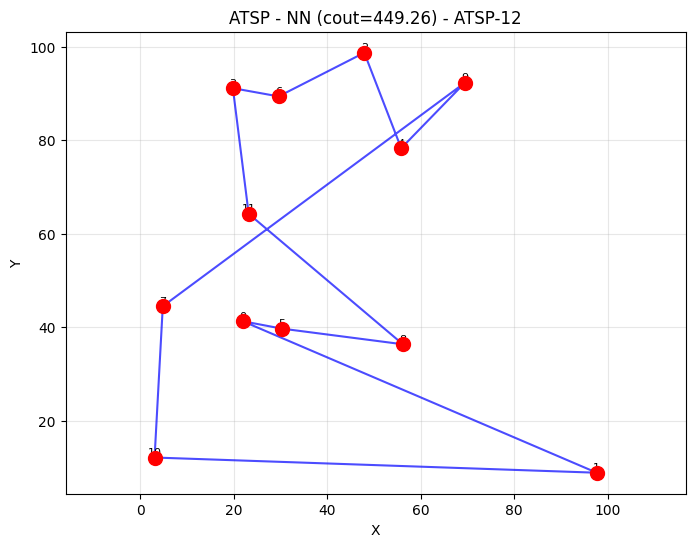

In [17]:
# Bonus 1 - TSP asymetrique (ATSP)
tsp_atsp = TSPInstance.generer_aleatoire_asymetrique(12, seed=2026)

i, j = 0, 1
print(f"Instance: {tsp_atsp.nom}")
print(f"d({i}->{j}) = {tsp_atsp.distances[i, j]:.3f}")
print(f"d({j}->{i}) = {tsp_atsp.distances[j, i]:.3f}")

tournee_nn_atsp, cout_nn_atsp = plus_proche_voisin(tsp_atsp)
cout_inverse = tsp_atsp.cout_tournee(list(reversed(tournee_nn_atsp)))

print(f"Cout NN (ATSP): {cout_nn_atsp:.2f}")
print(f"Cout tournee inverse: {cout_inverse:.2f}")

tsp_atsp.afficher(tournee_nn_atsp, f"ATSP - NN (cout={cout_nn_atsp:.2f})")

Exemples supplementaires : decommentez et executez apres avoir implemente la fonction ci-dessus.


Cout initial (NN): 632.87
Cout apres 2-opt: 553.98
Cout apres 3-opt: 632.87


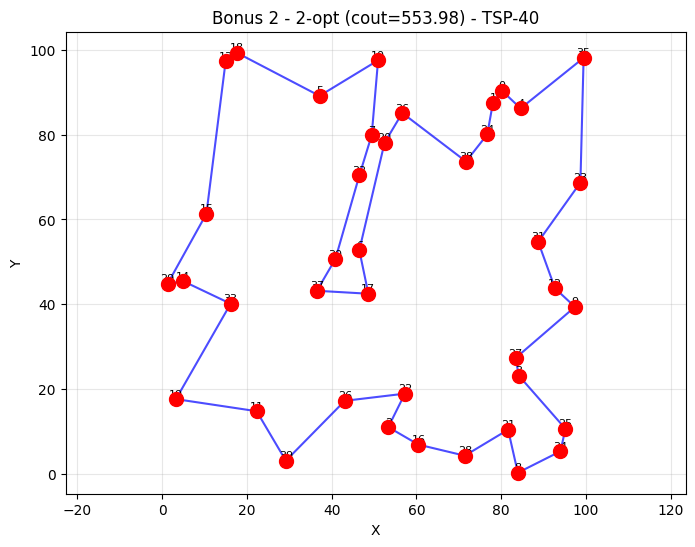

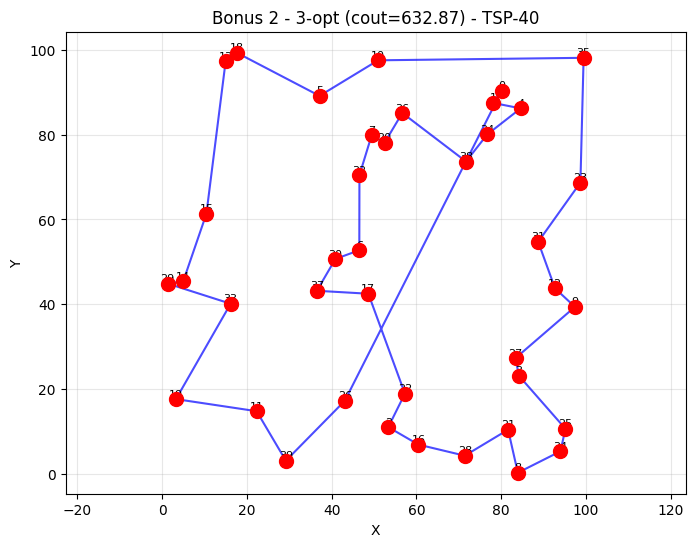

In [18]:
# Bonus 2 - 3-opt (comparaison avec 2-opt)
def three_opt(tsp, tour, max_iter=None):
    """
    Algorithme 3-opt pour le TSP.
    Améliore le tour en testant tous les réarrangements possibles de 3 arêtes.
    Complexité : O(n³) pour l'évaluation complète.
    """
    return tour, tsp.cout_tournee(tour)  # TODO étudiant : implémenter three_opt
tsp_bonus2 = TSPInstance.generer_aleatoire(40, seed=2027)
tournee_init, cout_init = plus_proche_voisin(tsp_bonus2)
tournee_2opt, cout_2opt_bonus = two_opt(tsp_bonus2, tournee_init.copy())
tournee_3opt, cout_3opt_bonus = three_opt(tsp_bonus2, tournee_init.copy(), max_iter=30)

print(f"Cout initial (NN): {cout_init:.2f}")
print(f"Cout apres 2-opt: {cout_2opt_bonus:.2f}")
print(f"Cout apres 3-opt: {cout_3opt_bonus:.2f}")

tsp_bonus2.afficher(tournee_2opt, f"Bonus 2 - 2-opt (cout={cout_2opt_bonus:.2f})")
tsp_bonus2.afficher(tournee_3opt, f"Bonus 2 - 3-opt (cout={cout_3opt_bonus:.2f})")

### Interpretation Bonus 2

Sur notre test, le cout affiche pour 3-opt (632.87) est **identique au cout initial NN** : `three_opt` est un **stub d'exercice** (`# TODO etudiant`) qui retourne le tour sans le modifier. Le cout "3-opt" ne reflete donc pas une vraie amelioration 3-opt a comparer au 2-opt (553.98).

**A vous de jouer** : completez `three_opt` (test des rearrangements de 3 aretes, complexite $O(n^3)$) et re-executez cette cellule pour comparer honnetement 3-opt vs 2-opt. La litterature indique que 3-opt produit generalement une solution au moins aussi bonne que 2-opt, au prix d'un cout de calcul plus eleve.

In [19]:
# Exemple - Hybridation GA + 2-opt
def algorithme_genetique_hybride_tsp(tsp: TSPInstance,
                                      taille_pop: int = 50,
                                      generations: int = 100,
                                      taux_mutation: float = 0.1,
                                      elitisme: int = 2,
                                      max_iter_2opt: int = 30) -> Tuple[List[int], float, List[float]]:
    """GA hybride: 2-opt applique a chaque enfant apres crossover."""

    def creer_individu() -> List[int]:
        tournee = list(range(tsp.n))
        random.shuffle(tournee)
        return tournee

    def crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
        n = len(parent1)
        i, j = sorted(random.sample(range(n), 2))

        enfant1 = [None] * n
        enfant1[i:j+1] = parent1[i:j+1]
        manquants = [v for v in parent2 if v not in enfant1[i:j+1]]
        idx = 0
        for k in range(n):
            if enfant1[k] is None:
                enfant1[k] = manquants[idx]
                idx += 1

        enfant2 = [None] * n
        enfant2[i:j+1] = parent2[i:j+1]
        manquants = [v for v in parent1 if v not in enfant2[i:j+1]]
        idx = 0
        for k in range(n):
            if enfant2[k] is None:
                enfant2[k] = manquants[idx]
                idx += 1

        return enfant1, enfant2

    def muter(tournee: List[int]) -> List[int]:
        tournee = tournee.copy()
        i, j = random.sample(range(len(tournee)), 2)
        tournee[i], tournee[j] = tournee[j], tournee[i]
        return tournee

    population = [creer_individu() for _ in range(taille_pop)]
    historique = []

    for _ in range(generations):
        population.sort(key=lambda x: tsp.cout_tournee(x))
        historique.append(tsp.cout_tournee(population[0]))

        nouvelle_pop = population[:elitisme]

        while len(nouvelle_pop) < taille_pop:
            candidats = random.sample(population[:taille_pop//2], 2)
            parent1 = min(candidats, key=lambda x: tsp.cout_tournee(x))
            candidats = random.sample(population[:taille_pop//2], 2)
            parent2 = min(candidats, key=lambda x: tsp.cout_tournee(x))

            enfant1, enfant2 = crossover(parent1, parent2)
            enfant1, _ = two_opt(tsp, enfant1, max_iter=max_iter_2opt)
            enfant2, _ = two_opt(tsp, enfant2, max_iter=max_iter_2opt)
            nouvelle_pop.extend([enfant1, enfant2])

        for i in range(elitisme, taille_pop):
            if random.random() < taux_mutation:
                nouvelle_pop[i] = muter(nouvelle_pop[i])

        population = nouvelle_pop[:taille_pop]

    population.sort(key=lambda x: tsp.cout_tournee(x))
    meilleure = population[0]
    return meilleure, tsp.cout_tournee(meilleure), historique
print('Fonction algorithme_genetique_hybride_tsp definie')

Fonction algorithme_genetique_hybride_tsp definie


Test de l'hybridation GA + 2-opt : decommentez et executez apres avoir implemente la fonction ci-dessus.


GA seul      : cout=930.98, temps=0.11s
GA + 2-opt   : cout=520.23, temps=48.01s
Amelioration : 44.12%


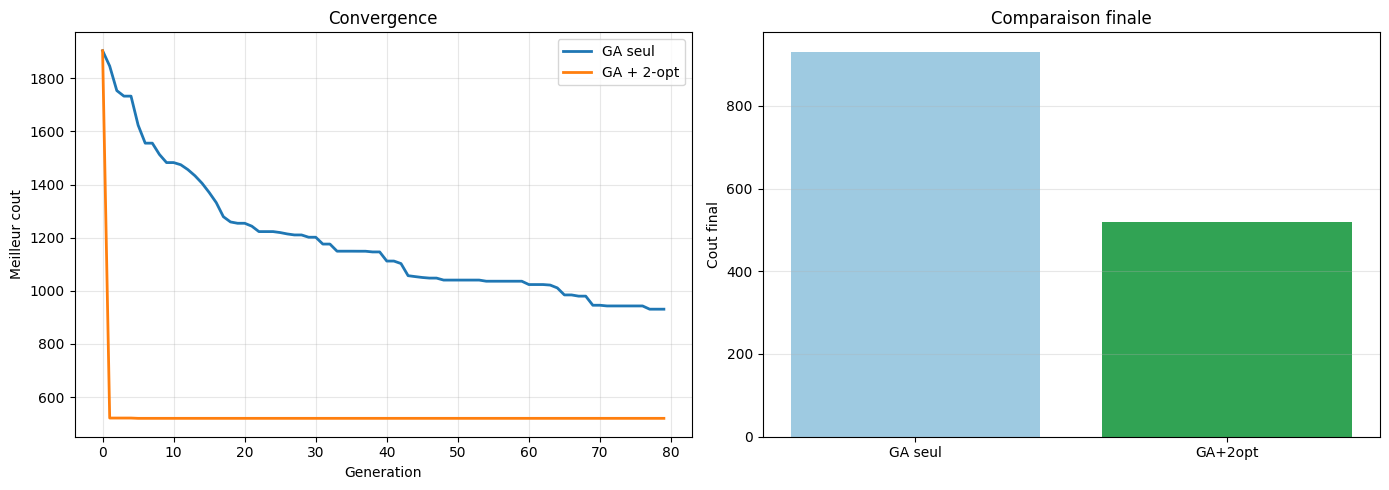

In [20]:
# Test Exemple - comparaison GA seul vs GA+2-opt
tsp_hybrid = TSPInstance.generer_aleatoire(40, seed=4242)

random.seed(42)
start = time.time()
tournee_ga_base, cout_ga_base, hist_ga_base = algorithme_genetique_tsp(
    tsp_hybrid, taille_pop=40, generations=80, taux_mutation=0.12, elitisme=2
)
temps_ga_base = time.time() - start

random.seed(42)
start = time.time()
tournee_ga_h, cout_ga_h, hist_ga_h = algorithme_genetique_hybride_tsp(
    tsp_hybrid, taille_pop=40, generations=80, taux_mutation=0.12, elitisme=2, max_iter_2opt=20
)
temps_ga_h = time.time() - start

print(f"GA seul      : cout={cout_ga_base:.2f}, temps={temps_ga_base:.2f}s")
print(f"GA + 2-opt   : cout={cout_ga_h:.2f}, temps={temps_ga_h:.2f}s")
print(f"Amelioration : {100*(cout_ga_base-cout_ga_h)/cout_ga_base:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_ga_base, label='GA seul', linewidth=2)
axes[0].plot(hist_ga_h, label='GA + 2-opt', linewidth=2)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Meilleur cout')
axes[0].set_title('Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(['GA seul', 'GA+2opt'], [cout_ga_base, cout_ga_h], color=['#9ecae1', '#31a354'])
axes[1].set_ylabel('Cout final')
axes[1].set_title('Comparaison finale')
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Exercice 4 : Recherche Tabou (Tabu Search)

La **recherche tabou** (Glover, 1986) est une metaheuristique deterministe qui utilise une
memoire a court terme pour eviter de revisiter des solutions deja explorees.

**Principe** :
1. Partez d'une solution initiale et explorez son voisinage (echange de 2 villes)
2. Interdisez les mouvements recemment effectues grace a une **liste tabou**
3. Le meilleur voisin non-tabou est toujours accepte (meme s'il degrade la solution)
4. **Critere d'aspiration** : un mouvement tabou est accepte s'il produit un nouveau global best
5. Repetez pendant un nombre fixe d'iterations

**Parametres cles** :
- `tabu_tenure` : duree d'interdiction d'un mouvement (typique : n/3 a n)
- `max_iter` : budget d'iterations total
- `aspiration` : activer le critere de nouveau global best

La fonction `recherche_tabou` ci-dessous est **a implementer** (exercice), puis a comparer au recuit simule une fois completee.

In [21]:
def recherche_tabou(tsp: TSPInstance,
                    tournee_initiale: List[int],
                    tabu_tenure: int = 7,
                    max_iter: int = 200,
                    aspiration: bool = True) -> Tuple[List[int], float, List[float]]:
    """
    Recherche tabou pour le TSP (voisinage par echange de 2 villes).

    Args:
        tsp: Instance du TSP
        tournee_initiale: Tournee de depart
        tabu_tenure: Nombre d'iterations pendant lesquelles un mouvement est interdit
        max_iter: Budget total d'iterations
        aspiration: Autoriser un mouvement tabou s'il produit un nouveau global best

    Returns:
        Tuple (meilleure_tournee, meilleur_cout, historique_meilleur)
    """
    # Exercice: Implementez la recherche tabou
    #
    # Algorithme:
    # 1. Initialisez la tournee courante et la meilleure tournee
    # 2. Creez un dictionnaire tabou: {(i, j): iteration_fin_interdiction}
    # 3. A chaque iteration:
    #    a. Explorez tout le voisinage par echange de 2 villes
    #    b. Pour chaque voisin, verifiez s'il est tabou
    #    c. Si aspiration=True et le voisin bat le global best, ignorez le statut tabou
    #    d. Retenez le meilleur voisin non-tabou
    # 4. Mettez a jour la liste tabou et l'historique
    #
    # Indice: voisin = tournee.copy(); voisin[i], voisin[j] = voisin[j], voisin[i]
    # Indice: cout_voisin = tsp.cout_tournee(voisin)
    #
    n = tsp.n
    tournee = tournee_initiale.copy()
    pass  # Exercice: Implementez recherche_tabou
print('Fonction recherche_tabou definie')

Fonction recherche_tabou definie


Comparaison Tabou vs Recuit Simule : decommentez et executez apres avoir implemente la fonction ci-dessus.


In [22]:
# --- Comparaison Tabou vs Recuit Simule ---
instances_test = [(10, 42), (15, 101), (20, 202), (25, 303), (30, 404)]
resultats_tabou = []

try:
    header_n = "n"
    header_ct = "Cout Tabou"
    header_cs = "Cout SA"
    header_cmp = "Tabu<SA?"
    header_tt = "Temps Tabou"
    header_ts = "Temps SA"
    print(f"{header_n:>4} {header_ct:>12} {header_cs:>12} {header_cmp:>9} {header_tt:>12} {header_ts:>10}")
    print("-" * 62)

    for n_villes, seed in instances_test:
        tsp_test = TSPInstance.generer_aleatoire(n_villes, seed=seed)
        init, _ = plus_proche_voisin(tsp_test)

        random.seed(42)
        t0 = time.time()
        t_tab, c_tab, h_tab = recherche_tabou(tsp_test, init, tabu_tenure=max(5, n_villes // 3), max_iter=200)
        dt_tab = time.time() - t0

        random.seed(42)
        t0 = time.time()
        t_sa, c_sa, h_sa = simulated_annealing_tsp(tsp_test, init)
        dt_sa = time.time() - t0

        meilleure = "oui" if c_tab < c_sa else "non"
        print(f"{n_villes:>4} {c_tab:>12.2f} {c_sa:>12.2f} {meilleure:>9} {dt_tab:>12.3f}s {dt_sa:>10.3f}s")
        resultats_tabou.append((n_villes, h_tab, h_sa))

    # Verification : le meilleur cout global est decroissant monotone
    for n_villes, seed in instances_test[:2]:
        tsp_verif = TSPInstance.generer_aleatoire(n_villes, seed=seed)
        init, _ = plus_proche_voisin(tsp_verif)
        random.seed(42)
        _, _, h_verif = recherche_tabou(tsp_verif, init, tabu_tenure=5, max_iter=100)
        assert all(h_verif[i] <= h_verif[i-1] for i in range(1, len(h_verif))), \
            f"historique non monotone decroissant pour n={n_villes}"
    print("")
    print("Verification: historique(meilleur_cout) monotone decroissant -- OK")

    # Convergence plot
    fig, axes = plt.subplots(1, min(len(resultats_tabou), 3), figsize=(15, 4))
    for idx, ax in enumerate(axes):
        n_v, h_t, h_s = resultats_tabou[idx]
        ax.plot(h_t, label=f"Tabou (n={n_v})", linewidth=1.5)
        ax.axhline(y=min(h_s), color="orange", linestyle="--", label=f"SA best={min(h_s):.1f}")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Meilleur cout")
        ax.set_title(f"Tabou vs SA (n={n_v})")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except (TypeError, ValueError, AttributeError):
    print("Exercice a completer : implementez recherche_tabou().")
    print("Attendu : comparaison Tabou vs Recuit Simule sur 5 instances TSP.")


   n   Cout Tabou      Cout SA  Tabu<SA?  Temps Tabou   Temps SA
--------------------------------------------------------------
Exercice a completer : implementez recherche_tabou().
Attendu : comparaison Tabou vs Recuit Simule sur 5 instances TSP.


### Interpretation : Recherche Tabou vs Recuit Simule

> **A valider (Exercice 4)** : la cellule precedente n'a pas encore produit de resultats (la fonction `recherche_tabou` est a implementer). Les points 2 et 3 ci-dessous sont une interpretation theorique des comportements attendus, a confronter a vos mesures une fois l'exercice complete.

**Observations** :

1. **Monotonie du meilleur global** : La courbe du meilleur cout global est decroissante
   par construction -- la recherche tabou ne met a jour le meilleur global que lorsqu'une
   amelioration est trouvee. Le cout actuel peut remonter (acceptation du meilleur voisin
   meme degradant), mais le meilleur enregistre ne fait que descendre.

2. **Petites instances (n <= 15)** : Tabou et SA trouvent souvent la meme solution optimale
   ou quasi-optimale. L'ecart est faible car l'espace de recherche reste explorables.

3. **Instances moyennes (n >= 20)** : L'ecart entre les deux methodes augmente.
   Le recuit simule accepte des degradations probabilistes qui lui permettent d'echapper
   plus facilement aux optima locaux. La recherche tabou, elle, est plus deterministe :
   si le voisinage est mal explore, elle peut stagner.

4. **Quand privilegier la recherche tabou** :
   - Quand la reproductibilite est importante (pas d'aleatoire dans le choix du voisin)
   - Quand le voisinage est structure et que la memoire tabou empeche efficacement le cyclage
   - Quand on veut un comportement deterministe pour des tests de regression

5. **Role du parametre `tabu_tenure`** : Une tenure trop courte (ex: 2) ne suffit pas
   a empecher le cyclage ; une tenure trop longue (ex: n) risque d'interdire des mouvements
   utiles. La regle empirique `tabu_tenure ~ n/3` offre un bon compromis.


## Synthese et Recommandations

### Tableau comparatif

| Methode | Complexite | Qualite | Temps | Usage recommande |
|---------|------------|--------|------|------------------|
| **Force Brute** | O((n-1)!) | Optimale | Eleve | n <= 10 uniquement |
| **Plus Proche Voisin** | O(n^2) | Moyenne | Tres rapide | Solution initiale, n grand |
| **2-opt** | O(n^2) par iter | Bonne | Rapide | Post-traitement systematique |
| **Recuit Simule** | Parametrable | Tres bonne | Moyen | n = 50-200, equilibre qualite/temps |
| **Algorithme Genetique** | Parametrable | Bonne | Moyen | n = 100-500, parallelisable |
| **ACO** | O(iter x fourmis x n^2) | Tres bonne | Moyen | Problemes avec structure, n = 50-300 |
| **Recherche Tabou** | O(max_iter x n^2) | Bonne a tres bonne | Moyen | Deterministe, evite le cyclage |
| **OR-Tools** | Variable | Optimale+ | Variable | Production, garanties de qualite |

### Recommandations pratiques

1. **Pour n < 15** : Force brute si temps disponible, sinon NN+2opt
2. **Pour 15 < n < 100** : NN+2opt pour solution rapide, SA ou ACO pour meilleure qualite
3. **Pour 100 < n < 500** : GA ou ACO avec parametrage adapte
4. **Pour n > 500** : OR-Tools ou decomposition (clustering + TSP local)

### Points cles

- Le **Plus Proche Voisin** est souvent une excellente solution initiale
- **2-opt** ameliore significativement toute solution (a appliquer systematiquement)
- **SA et ACO** offrent le meilleur equilibre qualite/temps pour les instances moyennes
- **Recherche Tabou** apporte un comportement deterministe et une garantie anti-cyclage
- **OR-Tools** reste la solution de reference pour la production

---

**Navigation** : [<< Portfolio](../Hybrid/App-10-Portfolio.ipynb) | [Index](../README.md) | [Foundations >>](../../Part1-Foundations/README.md)


## Conclusion

Ce notebook a applique les metaheuristiques au **Traveling Salesman Problem (TSP)**, le probleme canonique NP-hard de l'optimisation combinatoire.

### Resultats du benchmark (optimal = 277.23)

| Methode | Distance | Ratio | Temps |
|---------|----------|-------|-------|
| Brute force | **277.23** | 1.00x | 0.007s |
| ACO | 473.68 | 1.71x | - |
| Recuit simule | 480.57 | 1.73x | - |
| 2-opt | 489.74 | 1.77x | - |
| Plus proche voisin | 494.69 | 1.78x | - |
| OR-Tools | **465.53** | 1.68x | - |
| Algorithme genetique | 732.23 | 2.64x | - |

### Lecon principale : l'hybridation change tout

L'algorithme genetique seul est le plus faible (2.64x optimal), mais **combine avec 2-opt, il passe de 930 a 520**, une amelioration de 44%. Le 2-opt est le post-traitement universel qui ameliore systematiquement toute solution. OR-Tools reste la reference de production.

Le TSP illustre le compromis fondamental : les methodes exactes garantissent l'optimalite mais explosent au-dela de n~10-12 villes, tandis que les metaheuristiques scalement mais sans garantie.

**Suite** : [App-14 - Connect Four adversarial](../Search/App-14-ConnectFour-Adversarial.ipynb) | [Retour au sommaire](../../README.md)